# Notebook 05 — Metric Estimation

**Pipeline:** Adaptive Classical Vision Pipeline for Cut-Edge Detection  
**Step 5:** Detected cut edges → 10 sampling points → metric distances in mm

**Input:**
- Detected lines from `outputs/04_hough/lines.json`
- Calibration data from `outputs/02_rectified/calibration.json`
- Rectified images from `outputs/02_rectified/`

**Output:**
- Metric measurements saved to `outputs/05_metric/measurements.json`
- Visualisations saved to `outputs/05_metric/`

**Key idea:** For each detected cut edge, extract 10 equally spaced sampling points
along the line. Using the px/mm scale factor from the QR calibration, convert
pixel coordinates to metric positions in mm referenced to the TL QR exterior corner.
Then compute the distance from each sampling point to the bottom border of the table.

## 1. Imports and configuration

In [1]:
!pip install opencv-python numpy matplotlib

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import json
from pathlib import Path

In [3]:
# ── Paths ──────────────────────────────────────────────────────────────────
RECTIFIED_DIR = Path("outputs/02_rectified")
CALIB_PATH    = RECTIFIED_DIR / "calibration.json"
LINES_PATH    = Path("outputs/04_hough/lines.json")
OUTPUT_DIR    = Path("outputs/05_metric")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Metric parameters ──────────────────────────────────────────────────────
N_SAMPLE_POINTS = 10   # number of equally spaced points per cut edge

# Load data
with open(CALIB_PATH) as f:
    calibration_data = json.load(f)
with open(LINES_PATH) as f:
    hough_results = json.load(f)

print(f"Calibrated images : {len(calibration_data)}")
print(f"Images with lines : {len(hough_results)}")
print(f"Output dir        : {OUTPUT_DIR.resolve()}")

Calibrated images : 22
Images with lines : 22
Output dir        : C:\Users\david\OneDrive\Documentos\UNI\VISION ARTIFICIAL\VA_RetoMichelin\models\David\outputs\05_metric


## 2. Pixel to metric conversion

The calibration from Notebook 02 gives us:
- `px_per_mm`: how many pixels correspond to 1 mm
- `corners_px`: the pixel coordinates of the TL, TR, BR QR exterior corners

The metric coordinate system has its origin at the TL QR exterior corner.
To convert a pixel coordinate `(px, py)` to mm:
```
x_mm = (px - tl_x) / px_per_mm
y_mm = (py - tl_y) / px_per_mm
```
The bottom border of the table is at `y = 800 mm` (the leg length of the QR triangle).

In [4]:
def px_to_mm(px: float, py: float, calib: dict) -> tuple[float, float]:
    """
    Convert pixel coordinates to metric coordinates (mm).

    Origin is at the TL QR exterior corner.
    x increases rightward, y increases downward.

    Parameters
    ----------
    px, py : float — pixel coordinates
    calib  : calibration dict for this image

    Returns
    -------
    x_mm, y_mm : float — metric coordinates in mm
    """
    tl_x, tl_y = calib['corners_px'][0]   # TL exterior corner in pixels
    scale       = calib['px_per_mm']       # px per mm

    x_mm = (px - tl_x) / scale
    y_mm = (py - tl_y) / scale

    return float(x_mm), float(y_mm)

## 3. Sampling points and distance estimation

For each detected cut edge (a vertical line segment), we:
1. Extract N equally spaced points along the segment
2. Convert each point from pixels to mm
3. Compute the distance from each point to the bottom border (y = 800 mm)

In [5]:
def sample_edge_points(x1: int, y1: int, x2: int, y2: int,
                       n: int = N_SAMPLE_POINTS) -> list[tuple[float, float]]:
    """
    Extract n equally spaced points along a line segment.

    Parameters
    ----------
    x1, y1, x2, y2 : int — segment endpoints in pixels
    n               : int — number of sample points

    Returns
    -------
    points : list of (px, py) tuples in pixel coordinates
    """
    ts = np.linspace(0, 1, n)
    points = [
        (float(x1 + t * (x2 - x1)), float(y1 + t * (y2 - y1)))
        for t in ts
    ]
    return points


def compute_distances(edge_px: list, calib: dict,
                      qr_leg_mm: float = 800.0) -> dict:
    """
    Compute metric positions and distances for one cut edge.

    Parameters
    ----------
    edge_px   : [x1, y1, x2, y2] — cut edge endpoints in pixels
    calib     : calibration dict
    qr_leg_mm : known leg length of QR triangle in mm (= bottom border y)

    Returns
    -------
    dict with:
        sample_points_px : list of (px, py)
        sample_points_mm : list of (x_mm, y_mm)
        distances_mm     : list of distances to bottom border (mm)
        mean_dist_mm     : mean distance across the 10 points
        edge_x_mm        : mean x position of the edge in mm
    """
    x1, y1, x2, y2 = edge_px
    pts_px = sample_edge_points(x1, y1, x2, y2)
    pts_mm = [px_to_mm(px, py, calib) for px, py in pts_px]

    # Distance from each point to the bottom border (y = qr_leg_mm)
    distances = [float(qr_leg_mm - y_mm) for _, y_mm in pts_mm]

    return {
        'sample_points_px': [(round(px, 2), round(py, 2)) for px, py in pts_px],
        'sample_points_mm': [(round(x, 2), round(y, 2)) for x, y in pts_mm],
        'distances_mm'    : [round(d, 2) for d in distances],
        'mean_dist_mm'    : round(float(np.mean(distances)), 2),
        'edge_x_mm'       : round(float(np.mean([x for x, _ in pts_mm])), 2)
    }

## 4. Full pipeline per image

In [6]:
def process_image(image_name: str) -> dict | None:
    if image_name not in hough_results:
        print(f"  [SKIP] No lines for {image_name}")
        return None

    calib    = calibration_data[image_name]
    edges_px = hough_results[image_name]['cut_edges_px']

    if not edges_px:
        print(f"  [WARN] {image_name}: no cut edges detected")
        return None

    measurements = []
    for i, edge in enumerate(edges_px):
        m = compute_distances(edge, calib)
        m['edge_id'] = i
        measurements.append(m)

    return {
        'image_name'   : image_name,
        'px_per_mm'    : calib['px_per_mm'],
        'n_edges'      : len(measurements),
        'measurements' : measurements
    }

In [7]:
metric_results = {}

for image_name in calibration_data:
    result = process_image(image_name)
    if result is not None:
        metric_results[image_name] = result
        print(f"  [OK] {image_name:30s}  n_edges={result['n_edges']}")
        for m in result['measurements']:
            print(f"       edge {m['edge_id']}: "
                  f"x={m['edge_x_mm']:7.1f} mm  "
                  f"mean_dist={m['mean_dist_mm']:7.1f} mm")

# Save
out_path = OUTPUT_DIR / "measurements.json"
with open(out_path, "w") as f:
    json.dump(metric_results, f, indent=2)
print(f"\nSaved to {out_path}")

  [OK] Multimedia_31.jpg               n_edges=41
       edge 0: x=   34.0 mm  mean_dist=   27.1 mm
       edge 1: x=  182.6 mm  mean_dist=  589.9 mm
       edge 2: x=  190.3 mm  mean_dist=  642.1 mm
       edge 3: x=  189.7 mm  mean_dist=  495.1 mm
       edge 4: x=  190.9 mm  mean_dist=  214.0 mm
       edge 5: x=  195.8 mm  mean_dist=  206.6 mm
       edge 6: x=  190.6 mm  mean_dist=  531.6 mm
       edge 7: x=  187.8 mm  mean_dist=  214.0 mm
       edge 8: x=  768.2 mm  mean_dist=  154.4 mm
       edge 9: x=  181.9 mm  mean_dist=  592.1 mm
       edge 10: x=  191.2 mm  mean_dist=  680.5 mm
       edge 11: x=   33.0 mm  mean_dist=   26.2 mm
       edge 12: x=  192.4 mm  mean_dist=  220.8 mm
       edge 13: x=  773.8 mm  mean_dist=  212.2 mm
       edge 14: x=  187.2 mm  mean_dist=  673.7 mm
       edge 15: x=  201.4 mm  mean_dist=  142.7 mm
       edge 16: x=  188.4 mm  mean_dist=  236.9 mm
       edge 17: x=  183.8 mm  mean_dist=  545.5 mm
       edge 18: x=  770.1 mm  mean_dist=  

## 5. Visual inspection

Show the 10 sampling points overlaid on the rectified image for one example.

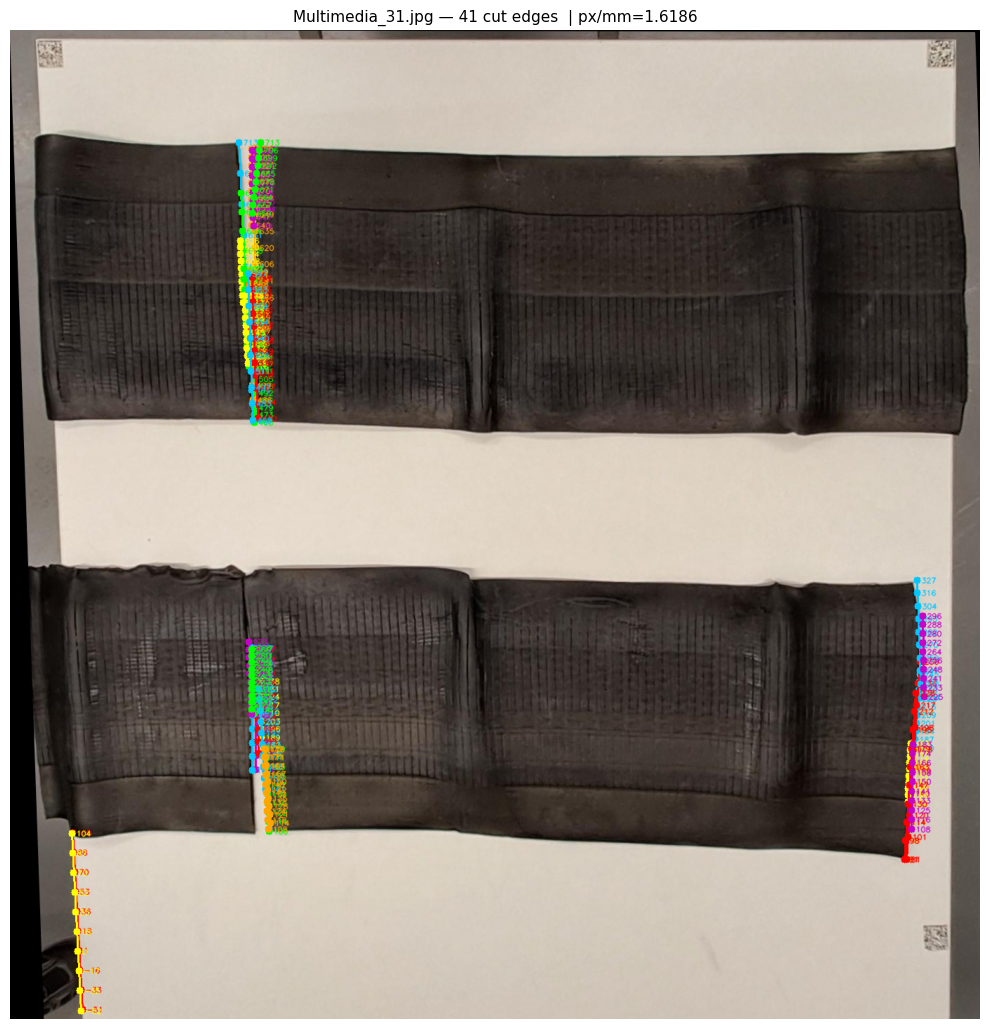

In [8]:
def visualize_measurements(image_name: str):
    result  = metric_results[image_name]
    img     = cv2.imread(str(RECTIFIED_DIR / image_name))
    overlay = cv2.cvtColor(img, cv2.COLOR_BGR2RGB).copy()

    colors = [(255,0,0), (0,200,255), (255,165,0), (0,255,0),
              (200,0,200), (255,255,0)]

    for m in result['measurements']:
        color = colors[m['edge_id'] % len(colors)]

        # Draw the edge line
        pts = m['sample_points_px']
        p_top = (int(pts[0][0]),  int(pts[0][1]))
        p_bot = (int(pts[-1][0]), int(pts[-1][1]))
        cv2.line(overlay, p_top, p_bot, color, 2)

        # Draw sampling points with distance labels
        for j, (px, py) in enumerate(pts):
            px_i, py_i = int(px), int(py)
            cv2.circle(overlay, (px_i, py_i), 5, color, -1)
            dist = m['distances_mm'][j]
            cv2.putText(overlay, f"{dist:.0f}",
                        (px_i + 6, py_i + 4),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.35,
                        color, 1, cv2.LINE_AA)

    fig, ax = plt.subplots(figsize=(10, 12))
    ax.imshow(overlay)
    ax.set_title(f"{image_name} — {result['n_edges']} cut edges  "
                 f"| px/mm={result['px_per_mm']:.4f}", fontsize=11)
    ax.axis('off')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"check_{image_name}", dpi=120)
    plt.show()


if metric_results:
    visualize_measurements(next(iter(metric_results)))
else:
    print("No results to visualize.")

In [9]:
# Visualize a specific image
# visualize_measurements("Multimedia_42.jpg")

## 6. Distance distribution across all images

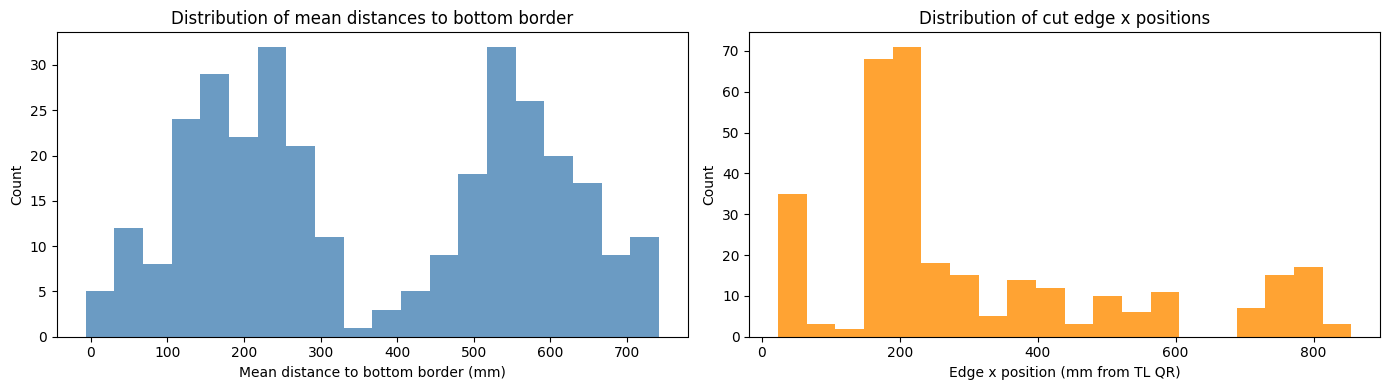

Mean distance to bottom : 369.3 mm
Std  distance to bottom : 208.3 mm
Mean edge x position    : 310.6 mm
Std  edge x position    : 221.4 mm


In [10]:
all_mean_dists = []
all_x_positions = []

for name, result in metric_results.items():
    for m in result['measurements']:
        all_mean_dists.append(m['mean_dist_mm'])
        all_x_positions.append(m['edge_x_mm'])

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(all_mean_dists, bins=20, color='steelblue', alpha=0.8)
axes[0].set_xlabel('Mean distance to bottom border (mm)')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of mean distances to bottom border')

axes[1].hist(all_x_positions, bins=20, color='darkorange', alpha=0.8)
axes[1].set_xlabel('Edge x position (mm from TL QR)')
axes[1].set_ylabel('Count')
axes[1].set_title('Distribution of cut edge x positions')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'distance_distribution.png', dpi=150)
plt.show()

print(f"Mean distance to bottom : {np.mean(all_mean_dists):.1f} mm")
print(f"Std  distance to bottom : {np.std(all_mean_dists):.1f} mm")
print(f"Mean edge x position    : {np.mean(all_x_positions):.1f} mm")
print(f"Std  edge x position    : {np.std(all_x_positions):.1f} mm")

## 7. Summary

| Step | Operation | Detail |
|------|-----------|--------|
| 5a | Sampling points | 10 equally spaced points per cut edge |
| 5b | px → mm conversion | using TL QR corner as origin and px_per_mm scale |
| 5c | Distance to bottom | `dist = 800 mm - y_mm` |

**Output folder:** `outputs/05_metric/`  
**Measurements file:** `outputs/05_metric/measurements.json`  
**Next notebook:** `06_evaluation.ipynb` — Evaluation against ground truth annotations